In [4]:
# Check Java version
!java -version
!which java

# If Java is not installed, install it:
!apt-get update
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# Set JAVA_HOME
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

openjdk version "11.0.28" 2025-07-15
OpenJDK Runtime Environment (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1)
OpenJDK 64-Bit Server VM (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)
/usr/bin/java
Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:7 https://cli.github.com/packages stable InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package 

In [5]:
from pyspark.sql import SparkSession

# Creating Spark session
spark = SparkSession.builder.appName("AmazonElectronicsSentimentAnalysis").getOrCreate()

In [6]:
# Reading the raw file as an RDD of lines
lines = spark.sparkContext.textFile("/content/Electronics.txt")

lines.take(20)

['product/productId: B0000630MQ',
 'product/title: Kodak Max K2000 Battery Charger with 4 NiMH AA Batteries',
 'product/price: unknown',
 'review/userId: A2F6FARSB1VL6Q',
 'review/profileName: "frumpy16"',
 'review/helpfulness: 2/2',
 'review/score: 5.0',
 'review/time: 1072915200',
 'review/summary: Great charger',
 'review/text: I recently bought this charger kit from Amazon and I am quite happy with my purchase. The folding plug is nice for storage. The included 1850 mAh batteries last for a long time in my Nikon Coolpix 2100. One of the best features of the charger is that each battery is charged separately (as opposed to in pairs) so that each battery gets just the right amount of charge. The short 3 hour charge time is great as well. The batteries do not get overly warm while charging either.Overall, this is a good charger for a good price. If you have a high drain device, the Kodak K2000 should keep you playing for a long time.',
 '',
 'product/productId: B0000630MQ',
 'product/

In [7]:
from pyspark.sql import SparkSession, Row


#Grouping lines by review (separated by blank lines)
reviews_rdd = lines.map(lambda x: x.strip()) \
                   .filter(lambda x: x != "") \
                   .zipWithIndex() \
                   .map(lambda x: (x[1] // 9, x[0])) \
                   .groupByKey() \
                   .map(lambda x: list(x[1]))

#Parse each grouped list into a dictionary
def parse_review(lines):
    review_dict = {
        "productId": None, "title": None, "price": None,
        "userId": None, "profileName": None, "helpfulness": None,
        "score": None, "time": None, "summary": None, "text": None
    }
    for line in lines:
        if ':' in line:
            key, value = line.split(':', 1)
            key = key.strip().replace("product/", "").replace("review/", "")
            review_dict[key] = value.strip()
    return Row(**review_dict)

#Applying parsed data and converting to DataFrame
parsed_rdd = reviews_rdd.map(parse_review)
df = spark.createDataFrame(parsed_rdd)

df.show(20)

+----------+--------------------+-------+--------------+--------------------+-----------+-----+----------+--------------------+--------------------+
| productId|               title|  price|        userId|         profileName|helpfulness|score|      time|             summary|                text|
+----------+--------------------+-------+--------------+--------------------+-----------+-----+----------+--------------------+--------------------+
|B0000630MQ|Kodak Max K2000 B...|unknown|A2F6FARSB1VL6Q|          "frumpy16"|        2/2|  5.0|1072915200|       Great charger|                NULL|
|B0000630MI|JVC HR-XVC1U DVD-...|unknown|       unknown|             unknown|       NULL|  5.0|1074470400|Great Combo Package!|I decided to wait...|
|B000ENKHPG|                NULL|unknown|A1YN69RGLGZIUQ|SBChristine "SBCh...|        1/1|  5.0|1176681600|Love it, love, lo...|I bought this tv ...|
|B0000DFZ2U|APC P1T 120V Port...|  13.89|A3FTMTQJXG8POL| Uncle Foobar "Foob"|      15/17|  4.0|      NULL|

In [8]:
df.printSchema()

root
 |-- productId: string (nullable = true)
 |-- title: string (nullable = true)
 |-- price: string (nullable = true)
 |-- userId: string (nullable = true)
 |-- profileName: string (nullable = true)
 |-- helpfulness: string (nullable = true)
 |-- score: string (nullable = true)
 |-- time: string (nullable = true)
 |-- summary: string (nullable = true)
 |-- text: string (nullable = true)



In [9]:
df.count()

1379754

In [10]:
#Showing structured and formatted DataFrame
selected_df = df.select("score", "summary", "text")

In [11]:
selected_df.show(20)

+-----+--------------------+--------------------+
|score|             summary|                text|
+-----+--------------------+--------------------+
|  5.0|       Great charger|                NULL|
|  5.0|Great Combo Package!|I decided to wait...|
|  5.0|Love it, love, lo...|I bought this tv ...|
|  4.0|$25K warranty isn...|This product desc...|
|  5.0|           Very Good|Just as promised,...|
|  4.0| Great value overall|                NULL|
|  5.0|Don't let Apple r...|This unit works v...|
|  4.0|macally powerbook...|Good product. A l...|
|  4.0|Intermittently ch...|Recently purchase...|
|  4.0|     Good product...|I got tired of pa...|
|  4.0| works fine, less $$|                NULL|
|  5.0|   Great Alternative|This is a great a...|
|  1.0|Buyer Beware!! Do...|I bought one of t...|
|  1.0|  Macally Power cord|Macally is a terr...|
|  4.0|Power Adapter for...|The cord works gr...|
|  5.0|    IBOOK AC ADAPTER|                NULL|
|  1.0|Stopped Working D...|Out of the diffic...|


In [12]:
df_clean = selected_df.na.drop(subset=["text", "score", "summary"])

In [13]:
df_clean.count()

965826

In [14]:
from pyspark.sql.functions import col, when, regexp_replace, lower, concat, lit

In [15]:
import re
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def clean_text(text):
    if text:
        text = text.lower()                              # Lowercase
        text = re.sub(r'\d+', '', text)                  # Remove numbers
        text = re.sub(r'[^\w\s]', '', text)              # Remove punctuation
        text = re.sub(r'\s+', ' ', text).strip()         # Remove extra spaces
        return text
    return ""

clean_text_udf = udf(clean_text, StringType())

In [16]:
df_cleaned = df_clean.withColumn("clean_summary", clean_text_udf("summary")) \
               .withColumn("clean_text", clean_text_udf("text"))

In [17]:
df_cleaned.show(20)

+-----+--------------------+--------------------+--------------------+--------------------+
|score|             summary|                text|       clean_summary|          clean_text|
+-----+--------------------+--------------------+--------------------+--------------------+
|  5.0|Great Combo Package!|I decided to wait...| great combo package|i decided to wait...|
|  5.0|Love it, love, lo...|I bought this tv ...|love it love love it|i bought this tv ...|
|  4.0|$25K warranty isn...|This product desc...|k warranty isnt i...|this product desc...|
|  5.0|           Very Good|Just as promised,...|           very good|just as promised ...|
|  5.0|Don't let Apple r...|This unit works v...|dont let apple ro...|this unit works v...|
|  4.0|macally powerbook...|Good product. A l...|macally powerbook...|good product a lo...|
|  4.0|Intermittently ch...|Recently purchase...|intermittently ch...|recently purchase...|
|  4.0|     Good product...|I got tired of pa...|        good product|i got tire

In [18]:
selected_clean_df = df_cleaned.select("score", "clean_summary", "clean_text")

In [19]:
from pyspark.sql.functions import concat_ws, col, lower

# Combining and converting to lowercase
combined_df = selected_clean_df.withColumn(
    "review_full",
    lower(concat_ws(" ", col("clean_summary"), col("clean_text")))
)


combined_df.show(10, truncate=False)

+-----+----------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [20]:
final_selected_df = combined_df.select("score", "review_full")

In [21]:
final_selected_df.show(20)

+-----+--------------------+
|score|         review_full|
+-----+--------------------+
|  5.0|great combo packa...|
|  5.0|love it love love...|
|  4.0|k warranty isnt i...|
|  5.0|very good just as...|
|  5.0|dont let apple ro...|
|  4.0|macally powerbook...|
|  4.0|intermittently ch...|
|  4.0|good product i go...|
|  5.0|great alternative...|
|  1.0|buyer beware does...|
|  1.0|macally power cor...|
|  4.0|power adapter for...|
|  1.0|stopped working d...|
|  5.0|samsung lnsd in l...|
|  5.0|warning cybershot...|
|  5.0|outstanding perfo...|
|  1.0|what a rip off so...|
|  5.0|works great i bou...|
|  5.0|yes it workstrobl...|
|  5.0|best printer i ha...|
+-----+--------------------+
only showing top 20 rows



In [22]:
my_df = final_selected_df.limit(500000)

In [23]:
my_df.show(20)

+-----+--------------------+
|score|         review_full|
+-----+--------------------+
|  5.0|great combo packa...|
|  5.0|love it love love...|
|  4.0|k warranty isnt i...|
|  5.0|very good just as...|
|  5.0|dont let apple ro...|
|  4.0|macally powerbook...|
|  4.0|intermittently ch...|
|  4.0|good product i go...|
|  5.0|great alternative...|
|  1.0|buyer beware does...|
|  1.0|macally power cor...|
|  4.0|power adapter for...|
|  1.0|stopped working d...|
|  5.0|samsung lnsd in l...|
|  5.0|warning cybershot...|
|  5.0|outstanding perfo...|
|  1.0|what a rip off so...|
|  5.0|works great i bou...|
|  5.0|yes it workstrobl...|
|  5.0|best printer i ha...|
+-----+--------------------+
only showing top 20 rows



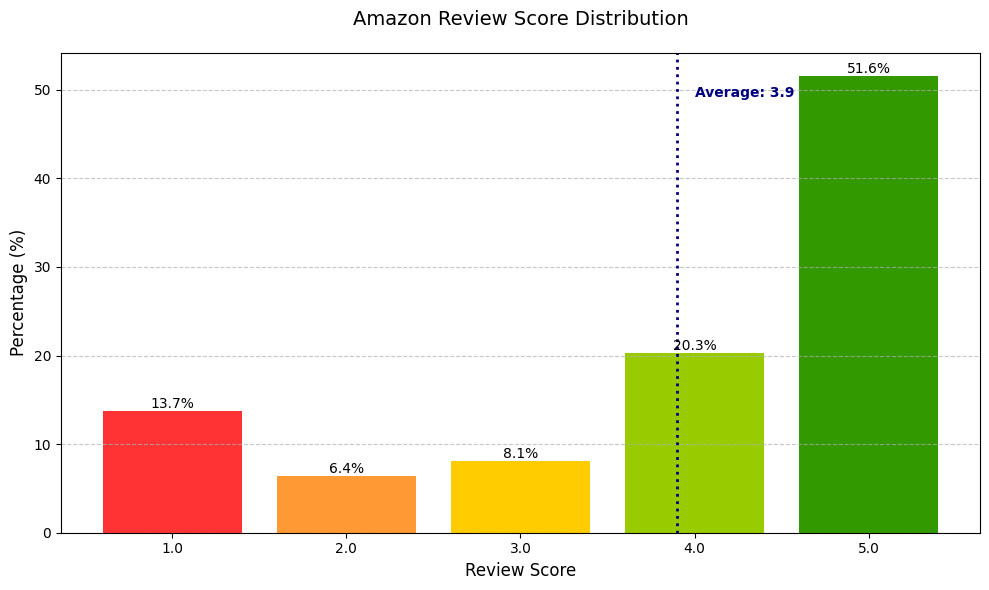

In [24]:
from pyspark.sql.functions import col, count, lit, round
import matplotlib.pyplot as plt

#Cleaning and preparing the data
rating_dist = (my_df
    .withColumn("score_clean", col("score").cast("float"))  # First convert to float
    .groupBy("score_clean")
    .agg(
        count("*").alias("count"),
        round(count("*") / my_df.count() * 100, 1).alias("percentage")  # Rounded percentage
    )
    .orderBy("score_clean")
    .toPandas())

#Converting score to star ratings (1-5)
rating_dist['score'] = rating_dist['score_clean'].astype(int)  # Now safe to convert
rating_dist = rating_dist[['score', 'count', 'percentage']]

# 3. Create the plot
plt.figure(figsize=(10, 6))
colors = ['#ff3333', '#ff9933', '#ffcc00', '#99cc00', '#339900']  # Red to green gradient
bars = plt.bar(rating_dist['score'], rating_dist['percentage'], color=colors)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom')

# Customize
plt.title('Amazon Review Score Distribution', fontsize=14, pad=20)
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rating_dist['score'], ['1.0', '2.0', '3.0', '4.0', '5.0'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add average line
avg_rating = (rating_dist['score'] * rating_dist['percentage']).sum() / 100
plt.axvline(x=avg_rating, color='navy', linestyle=':', linewidth=2)
plt.text(avg_rating + 0.1, plt.ylim()[1] - 5,
         f'Average: {avg_rating:.1f}',
         color='navy', fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
from pyspark.sql.functions import when

# Converting score to binary sentiment (1-2 as negative, 4-5 as positive)
my_df = my_df.withColumn("sentiment",
                  when(col("score") >= 4, 1)  # Positive
                  .when(col("score") <= 2, 0) # Negative
                  .otherwise(None))           # Neutral (can filter these out)

# Filtering out neutral reviews (score=3) for binary classification
my_df = my_df.filter(col("sentiment").isNotNull())

In [26]:
my_df.show(20)

+-----+--------------------+---------+
|score|         review_full|sentiment|
+-----+--------------------+---------+
|  5.0|great combo packa...|        1|
|  5.0|love it love love...|        1|
|  4.0|k warranty isnt i...|        1|
|  5.0|very good just as...|        1|
|  5.0|dont let apple ro...|        1|
|  4.0|macally powerbook...|        1|
|  4.0|intermittently ch...|        1|
|  4.0|good product i go...|        1|
|  5.0|great alternative...|        1|
|  1.0|buyer beware does...|        0|
|  1.0|macally power cor...|        0|
|  4.0|power adapter for...|        1|
|  1.0|stopped working d...|        0|
|  5.0|samsung lnsd in l...|        1|
|  5.0|warning cybershot...|        1|
|  5.0|outstanding perfo...|        1|
|  1.0|what a rip off so...|        0|
|  5.0|works great i bou...|        1|
|  5.0|yes it workstrobl...|        1|
|  5.0|best printer i ha...|        1|
+-----+--------------------+---------+
only showing top 20 rows



In [27]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (Tokenizer, StopWordsRemover, Word2Vec)
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when, regexp_replace, lower, concat, lit

In [28]:
tokenizer = Tokenizer(inputCol="review_full", outputCol="words")
stopwords_remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words",
    stopWords=StopWordsRemover.loadDefaultStopWords("english")  # Default English stopwords
)

In [29]:
# Word2Vec Embeddings
word2vec = Word2Vec(
    vectorSize=300,       # Larger dimension for better semantics
    minCount=10,          # Ignore rare words
    windowSize=5,         # Context window size
    inputCol="filtered_words",
    outputCol="word_embeddings"
)

In [30]:
layers = [300, 150, 50, 2]  # Architecture: input -> hidden -> hidden -> output
mlp = MultilayerPerceptronClassifier(
    layers=layers,
    featuresCol="word_embeddings",
    labelCol="sentiment",
    maxIter=100,
    blockSize=128,
    solver="l-bfgs"
)

In [31]:
pipeline = Pipeline(stages=[
    tokenizer,
    stopwords_remover,
    word2vec,
    mlp
])

In [32]:
train_data, test_data = my_df.randomSplit([0.7, 0.3], seed=42)

In [33]:
model = pipeline.fit(train_data)

In [34]:
predictions = model.transform(test_data)

In [35]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="sentiment",
    predictionCol="prediction",
    metricName="accuracy"
)

In [36]:
accuracy = evaluator.evaluate(predictions)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8806


In [37]:
# Precision
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="sentiment",
    predictionCol="prediction",
    metricName="weightedPrecision"
)
precision = precision_evaluator.evaluate(predictions)
print(f"Precision: {precision:.4f}")

Precision: 0.8754


In [38]:
# Recall
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="sentiment",
    predictionCol="prediction",
    metricName="weightedRecall"
)
recall = recall_evaluator.evaluate(predictions)
print(f"Recall: {recall:.4f}")

Recall: 0.8806


In [39]:
# F1 Score
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="sentiment",
    predictionCol="prediction",
    metricName="f1"
)
f1 = f1_evaluator.evaluate(predictions)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8757


In [40]:
# Confusion Matrix
predictions.groupBy("sentiment", "prediction").count().show()

+---------+----------+------+
|sentiment|prediction| count|
+---------+----------+------+
|        0|       0.0| 18924|
|        0|       1.0| 11201|
|        1|       0.0|  5293|
|        1|       1.0|102682|
+---------+----------+------+



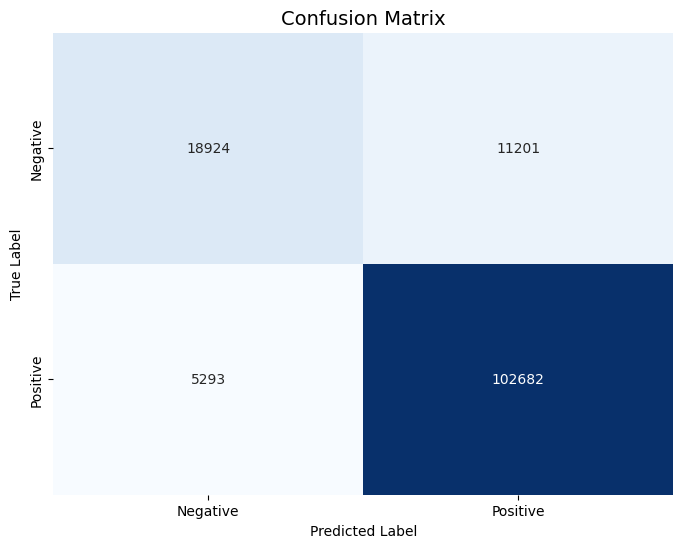

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Extract true/predicted labels
y_true = predictions.select("sentiment").rdd.flatMap(lambda x: x).collect()
y_pred = predictions.select("prediction").rdd.flatMap(lambda x: x).collect()

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = ["Negative", "Positive"]

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues',
            cbar=False)
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

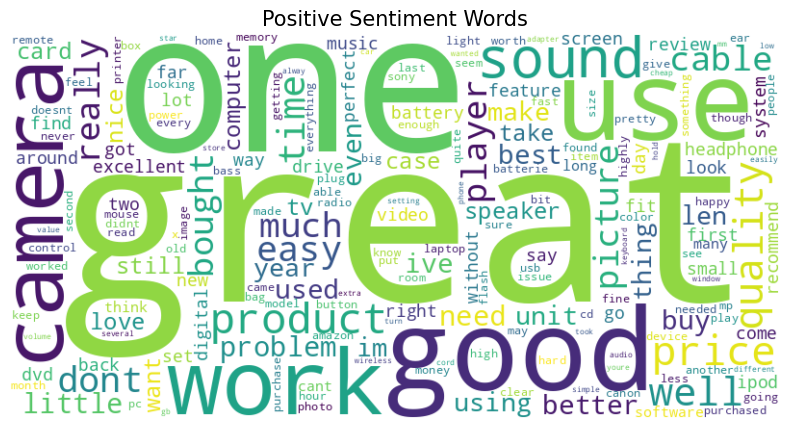

In [42]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

# Collecting positive and negative words
pos_words = (predictions
    .filter(col("sentiment") == 1)
    .select("filtered_words")
    .rdd.flatMap(lambda x: x[0])
    .collect())

neg_words = (predictions
    .filter(col("sentiment") == 0)
    .select("filtered_words")
    .rdd.flatMap(lambda x: x[0])
    .collect())

# Generating word clouds
def generate_wordcloud(words, title):
    wc = WordCloud(width=800, height=400,
                  background_color='white',
                  collocations=False).generate(" ".join(words))

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=15)
    plt.axis("off")
    plt.show()

generate_wordcloud(pos_words, "Positive Sentiment Words")

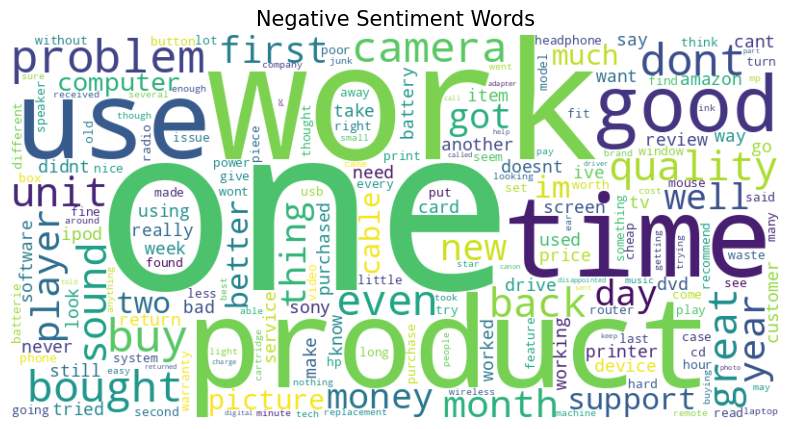

In [43]:
generate_wordcloud(neg_words, "Negative Sentiment Words")

In [43]:
model.save("sentiment_model")

In [43]:
# from pyspark.ml.pipeline import PipelineModel
# loaded_model = PipelineModel.load("sentiment_model")

In [48]:
model.save("/content/sentiment_model")


In [45]:
!ls -lh

total 1.1G
-rw-r--r-- 1 root root 1.1G Nov  6 22:13 Electronics.txt
drwxr-xr-x 1 root root 4.0K Nov  5 14:33 sample_data


In [47]:
!find / -type d -name "sentiment_model" 2>/dev/null


In [49]:
!zip -r sentiment_model.zip /content/sentiment_model
from google.colab import files
files.download("sentiment_model.zip")



  adding: content/sentiment_model/ (stored 0%)
  adding: content/sentiment_model/stages/ (stored 0%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/ (stored 0%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/metadata/ (stored 0%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/metadata/._SUCCESS.crc (stored 0%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/metadata/_SUCCESS (stored 0%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/metadata/.part-00000.crc (stored 0%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/metadata/part-00000 (deflated 40%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/data/ (stored 0%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/data/part-00000-f6165ba3-8365-47ab-828b-329a1f70f692-c000.snappy.parquet (deflated 7%)
  adding: content/sentiment_model/stages/2_Word2Vec_ba6847137b00/data/.part-00000-f6165ba3-8365-47ab-8

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
from pyspark.ml.pipeline import PipelineModel

# Load the model
model = PipelineModel.load("/content/sentiment_model")

# Load your dataset (example)
data = spark.read.csv("Electronics.txt", header=True, inferSchema=True, sep="\t")

# Transform the data to get predictions
predictions = model.transform(my_df)


In [53]:
predictions.columns


['score',
 'review_full',
 'sentiment',
 'words',
 'filtered_words',
 'word_embeddings',
 'rawPrediction',
 'probability',
 'prediction']

In [54]:
preds = predictions.select("review_full", "prediction", "probability")
preds.show(5)


+--------------------+----------+--------------------+
|         review_full|prediction|         probability|
+--------------------+----------+--------------------+
|great combo packa...|       1.0|[0.03794708266670...|
|love it love love...|       1.0|[0.02910499249537...|
|k warranty isnt i...|       0.0|[0.90429540990893...|
|very good just as...|       1.0|[0.02295601910573...|
|dont let apple ro...|       1.0|[0.22468814916005...|
+--------------------+----------+--------------------+
only showing top 5 rows



In [55]:
from pyspark.sql.functions import when

preds = preds.withColumn(
    "sentiment",
    when(preds.prediction == 0, "Negative")
    .when(preds.prediction == 1, "Positive")
)


In [58]:
# preds.toPandas().to_csv("/content/sentiment_predictions.csv", index=False)

# preds.write.csv("/content/sentiment_predictions", header=True, mode="overwrite")




from pyspark.sql.functions import col, udf
from pyspark.ml.linalg import VectorUDT
from pyspark.sql.types import FloatType

# Define a UDF to extract probability for class 1 (Positive)
get_positive_prob = udf(lambda v: float(v[1]), FloatType())

preds = preds.withColumn("positive_prob", get_positive_prob(col("probability")))
preds = preds.withColumn("negative_prob", 1 - col("positive_prob"))

# Drop the original 'probability' column
preds = preds.drop("probability")

preds.show(5, truncate=False)




+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [59]:
# Coalesce to 1 file for easier download
preds.coalesce(1).write.csv("/content/sentiment_predictions", header=True, mode="overwrite")

# Zip for download
!zip -r sentiment_predictions.zip /content/sentiment_predictions
from google.colab import files
files.download("/content/sentiment_predictions.zip")


  adding: content/sentiment_predictions/ (stored 0%)
  adding: content/sentiment_predictions/.part-00000-609f1af7-3ae0-4cf4-b845-730523440ca0-c000.csv.crc (deflated 0%)
  adding: content/sentiment_predictions/._SUCCESS.crc (stored 0%)
  adding: content/sentiment_predictions/_SUCCESS (stored 0%)
  adding: content/sentiment_predictions/part-00000-609f1af7-3ae0-4cf4-b845-730523440ca0-c000.csv (deflated 64%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("/content/sentiment_predictions.csv")
